## Step 1 — Import libraries

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

## Step 2 — Set project paths

In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
DASHBOARD_PATH = PROJECT_ROOT / "dashboard"
REPORT_PATH = PROJECT_ROOT / "reports"

DASHBOARD_PATH.mkdir(parents=True, exist_ok=True)
REPORT_PATH.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Processed Folder:", PROCESSED_PATH.exists())

Project Root: d:\Mutual_Fund_Analytics_IPYNB_Day1
Processed Folder: True


## Step 3 — Load required datasets

In [4]:
nav = pd.read_csv(PROCESSED_PATH / "clean_nav.csv")
performance = pd.read_csv(PROCESSED_PATH / "clean_performance.csv")
fund_master = pd.read_csv(PROCESSED_PATH / "dim_fund.csv")
benchmark = pd.read_csv(PROCESSED_PATH / "fact_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"], errors="coerce")
nav["nav"] = pd.to_numeric(nav["nav"], errors="coerce")

print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Fund Master:", fund_master.shape)
print("Benchmark:", benchmark.shape)

display(nav.head())

NAV: (46000, 4)
Performance: (40, 21)
Fund Master: (40, 15)
Benchmark: (8050, 3)


,amfi_code,date,nav,daily_return_pct
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999


## Step 4 — Calculate daily returns

In [5]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

daily_return_check = nav.groupby("amfi_code")["daily_return"].describe()

print("Daily returns calculated.")
display(nav.head())
display(daily_return_check.head())

Daily returns calculated.


,amfi_code,date,nav,daily_return_pct,daily_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-1.030568,-0.010306
2,100016,2022-01-05,521.7239,1.286515,0.012865
3,100016,2022-01-06,515.7880,-1.137747,-0.011377
4,100016,2022-01-07,515.1639,-0.120999,-0.001210


,count,mean,std,min,25%,50%,75%,max
amfi_code,,,,,,,,
100016,1149.0,0.000142,0.009164,-0.024744,-0.006282,-0.000070,0.006523,0.032145
100025,1149.0,0.000170,0.002460,-0.008188,-0.001445,0.000099,0.001824,0.008837
100033,1149.0,0.001080,0.011929,-0.044238,-0.006654,0.001086,0.008844,0.041954
101206,1149.0,0.000852,0.009177,-0.038121,-0.005733,0.000808,0.007165,0.033956
101207,1149.0,0.000424,0.016251,-0.051847,-0.010799,0.000182,0.011286,0.054851


## Step 5 — Calculate CAGR

In [6]:
cagr_data = []

for code, group in nav.groupby("amfi_code"):
    group = group.dropna(subset=["nav", "date"]).sort_values("date")
    
    if len(group) < 2:
        continue
    
    start_nav = group["nav"].iloc[0]
    end_nav = group["nav"].iloc[-1]
    start_date = group["date"].iloc[0]
    end_date = group["date"].iloc[-1]
    
    years = (end_date - start_date).days / 365.25
    
    if start_nav > 0 and years > 0:
        cagr = ((end_nav / start_nav) ** (1 / years)) - 1
    else:
        cagr = np.nan
    
    cagr_data.append({
        "amfi_code": code,
        "start_nav": start_nav,
        "end_nav": end_nav,
        "start_date": start_date,
        "end_date": end_date,
        "years": years,
        "cagr_pct": cagr * 100
    })

cagr_df = pd.DataFrame(cagr_data)

print("CAGR calculated.")
display(cagr_df.head())

CAGR calculated.


,amfi_code,start_nav,end_nav,start_date,end_date,years,cagr_pct
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,2.637074
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,4.458210
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,30.123153
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,23.538361
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,7.938765


## Step 6 — Calculate Sharpe ratio

In [7]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

sharpe_data = []

for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    
    if len(returns) == 0 or returns.std() == 0:
        sharpe = np.nan
    else:
        sharpe = ((returns.mean() - daily_rf) / returns.std()) * np.sqrt(252)
    
    sharpe_data.append({
        "amfi_code": code,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_data)

print("Sharpe ratio calculated.")
display(sharpe_df.head())

Sharpe ratio calculated.


,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


## Step 7 — Calculate Sortino ratio

In [8]:
sortino_data = []

for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    downside_returns = returns[returns < 0]
    
    if len(downside_returns) == 0 or downside_returns.std() == 0:
        sortino = np.nan
    else:
        sortino = ((returns.mean() - daily_rf) / downside_returns.std()) * np.sqrt(252)
    
    sortino_data.append({
        "amfi_code": code,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_data)

print("Sortino ratio calculated.")
display(sortino_df.head())

Sortino ratio calculated.


,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


## Step 8 — Calculate maximum drawdown

In [9]:
drawdown_data = []

for code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date").copy()
    
    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = (group["nav"] - group["running_max"]) / group["running_max"]
    
    max_drawdown = group["drawdown"].min()
    
    drawdown_data.append({
        "amfi_code": code,
        "max_drawdown_pct": max_drawdown * 100
    })

drawdown_df = pd.DataFrame(drawdown_data)

print("Maximum drawdown calculated.")
display(drawdown_df.head())

Maximum drawdown calculated.


,amfi_code,max_drawdown_pct
0,100016,-24.734441
1,100025,-4.308264
2,100033,-16.217209
3,101206,-11.291596
4,101207,-35.446916


## Step 9 — Prepare benchmark returns

In [11]:
print("Benchmark columns:")
print(benchmark.columns.tolist())
display(benchmark.head())

Benchmark columns:
['date', 'index_name', 'close_value', 'benchmark_return']


,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [12]:
date_col = "date" if "date" in benchmark.columns else "month"
benchmark_value_col = None

for col in benchmark.columns:
    if col.lower() in ["index_value", "close", "price", "value", "nifty_50", "nifty50"]:
        benchmark_value_col = col
        break

if benchmark_value_col is None:
    numeric_cols = benchmark.select_dtypes(include=["number"]).columns.tolist()
    benchmark_value_col = numeric_cols[-1]

benchmark[date_col] = pd.to_datetime(benchmark[date_col], errors="coerce")
benchmark = benchmark.sort_values(date_col)

benchmark["benchmark_return"] = benchmark[benchmark_value_col].pct_change()

benchmark_returns = benchmark[[date_col, "benchmark_return"]].rename(columns={date_col: "date"})

print("Benchmark return column used:", benchmark_value_col)
display(benchmark_returns.head())

Benchmark return column used: benchmark_return


,date,benchmark_return
0,2022-01-03,NaN
5750,2022-01-03,NaN
2300,2022-01-03,-4.750250
6900,2022-01-03,-1.260874
1150,2022-01-03,-14.225990


## Step 10 — Calculate Alpha and Beta

In [13]:
alpha_beta_data = []

for code, group in nav.groupby("amfi_code"):
    fund_returns = group[["date", "daily_return"]].dropna()
    
    merged = fund_returns.merge(benchmark_returns, on="date", how="inner").dropna()
    
    if len(merged) < 30:
        alpha = np.nan
        beta = np.nan
    else:
        X = merged["benchmark_return"]
        y = merged["daily_return"]
        X = sm.add_constant(X)
        
        model = sm.OLS(y, X).fit()
        alpha = model.params["const"] * 252
        beta = model.params["benchmark_return"]
    
    alpha_beta_data.append({
        "amfi_code": code,
        "alpha_pct": alpha * 100 if pd.notna(alpha) else np.nan,
        "beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_data)

alpha_beta_df.to_csv(PROCESSED_PATH / "alpha_beta.csv", index=False)

print("Alpha and Beta calculated.")
display(alpha_beta_df.head())

Alpha and Beta calculated.


,amfi_code,alpha_pct,beta
0,100016,3.605227,7.037862e-08
1,100025,4.282302,-5.819314e-09
2,100033,27.212347,2.459538e-09
3,101206,21.477789,2.501955e-08
4,101207,10.721976,4.910510e-08


## Step 11 — Create fund scorecard

In [14]:
scorecard = (
    cagr_df[["amfi_code", "cagr_pct"]]
    .merge(sharpe_df, on="amfi_code", how="left")
    .merge(sortino_df, on="amfi_code", how="left")
    .merge(drawdown_df, on="amfi_code", how="left")
    .merge(alpha_beta_df, on="amfi_code", how="left")
)

scorecard = scorecard.merge(
    fund_master[["amfi_code", "fund_house", "scheme_name", "category", "sub_category"]],
    on="amfi_code",
    how="left"
)

scorecard["cagr_rank"] = scorecard["cagr_pct"].rank(pct=True)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(pct=True)
scorecard["alpha_rank"] = scorecard["alpha_pct"].rank(pct=True)
scorecard["drawdown_rank"] = (-scorecard["max_drawdown_pct"]).rank(pct=True)

scorecard["expense_ratio_rank"] = 0.5

if "expense_ratio_pct" in performance.columns:
    expense = performance[["amfi_code", "expense_ratio_pct"]].copy()
    scorecard = scorecard.merge(expense, on="amfi_code", how="left")
    scorecard["expense_ratio_rank"] = (-scorecard["expense_ratio_pct"]).rank(pct=True)

scorecard["score"] = (
    30 * scorecard["cagr_rank"] +
    25 * scorecard["sharpe_rank"] +
    20 * scorecard["alpha_rank"] +
    15 * scorecard["expense_ratio_rank"] +
    10 * scorecard["drawdown_rank"]
)

scorecard["score"] = scorecard["score"].round(2)

scorecard = scorecard.sort_values("score", ascending=False)

scorecard.to_csv(PROCESSED_PATH / "fund_scorecard.csv", index=False)

print("Fund scorecard created.")
display(scorecard.head(10))

Fund scorecard created.


,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,alpha_pct,beta,fund_house,scheme_name,category,sub_category,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,expense_ratio_rank,expense_ratio_pct,score
25,120505,32.827406,1.180101,2.029353,-18.188514,29.260659,-8.794200e-09,ICICI Prudential MF,ICICI Pru Midcap Fund - Regular - Growth,Equity,Mid Cap,1.000,0.900,0.950,0.625,0.6500,1.36,87.50
21,119598,32.423536,0.945308,1.675317,-28.706006,30.273069,1.424313e-08,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,0.975,0.675,1.000,0.900,0.5000,1.43,82.62
39,149324,32.287440,0.949796,1.619793,-31.171900,30.104045,2.081768e-08,DSP Mutual Fund,DSP Small Cap Fund - Regular - Growth,Equity,Small Cap,0.950,0.700,0.975,0.925,0.3625,1.52,80.19
30,120843,30.907455,1.306744,2.364320,-12.973968,27.277879,3.365141e-08,Kotak Mahindra MF,Kotak Flexicap Fund - Regular - Growth,Equity,Flexi Cap,0.875,0.975,0.900,0.325,0.4750,1.45,79.00
2,100033,30.123153,1.093699,1.829134,-16.217209,27.212347,2.459538e-09,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,0.850,0.850,0.875,0.500,0.6000,1.38,78.25
34,148567,30.974108,1.448291,2.385644,-11.265729,27.021982,-6.602010e-08,Mirae Asset MF,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Large Cap,0.900,1.000,0.850,0.200,0.4500,1.46,77.75
36,148569,31.949523,1.234930,2.146914,-16.396743,28.345382,3.663460e-08,Mirae Asset MF,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,ELSS,0.925,0.950,0.925,0.525,0.1125,1.60,76.94
16,119094,28.214417,0.998231,1.703797,-20.960884,25.890114,3.302671e-08,Axis Mutual Fund,Axis Midcap Fund - Regular - Growth,Equity,Mid Cap,0.800,0.750,0.800,0.700,0.6000,1.38,74.75
9,118632,24.049493,1.081659,1.850133,-17.414075,21.812809,1.737035e-08,Nippon India MF,Nippon India Large Cap Fund - Regular - Growth,Equity,Large Cap,0.750,0.825,0.750,0.575,0.4125,1.51,70.06
19,119551,25.804686,1.208267,2.140267,-15.012385,23.095515,-1.486799e-08,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,0.775,0.925,0.775,0.425,0.2625,1.54,70.06


## Step 12 — Benchmark comparison chart

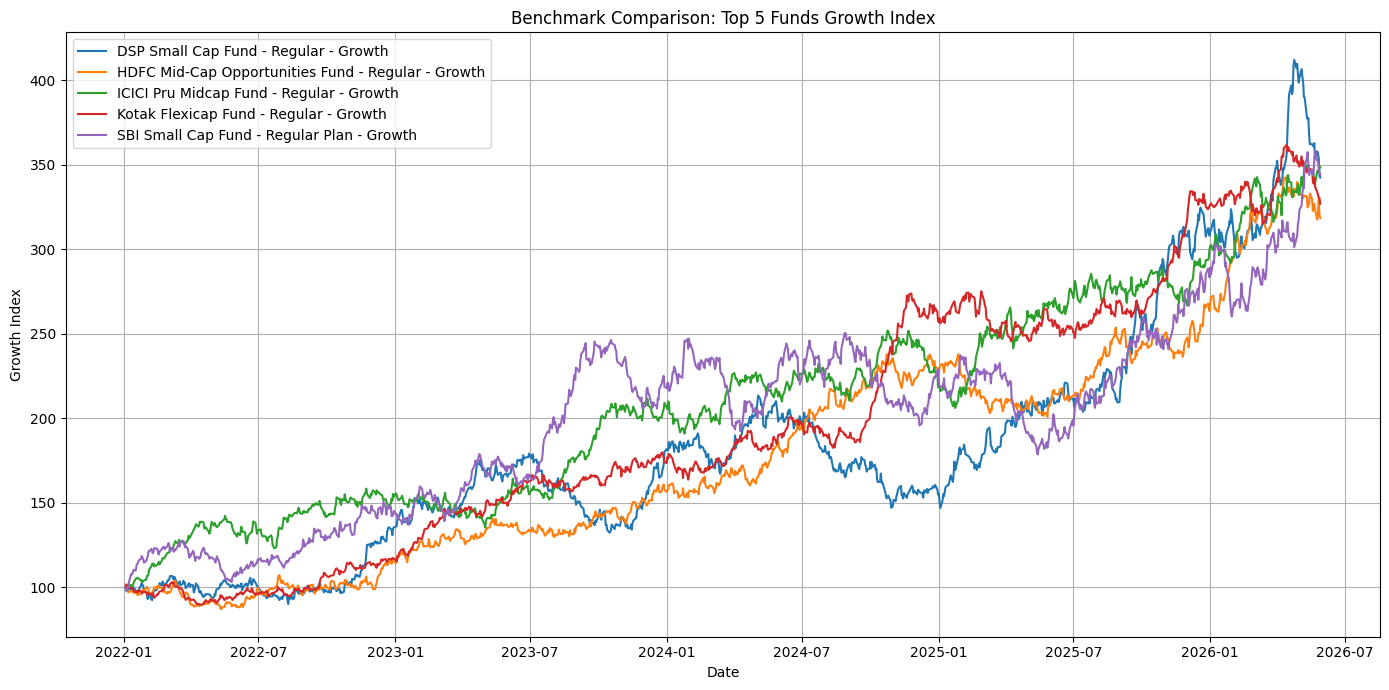

benchmark_comparison.png created.


In [15]:
top_funds = scorecard.head(5)["amfi_code"].tolist()

comparison_data = nav[nav["amfi_code"].isin(top_funds)].copy()

comparison_data = comparison_data.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

comparison_data = comparison_data.sort_values(["amfi_code", "date"])

comparison_data["growth_index"] = comparison_data.groupby("amfi_code")["nav"].transform(
    lambda x: (x / x.iloc[0]) * 100
)

plt.figure(figsize=(14, 7))

for name, group in comparison_data.groupby("scheme_name"):
    plt.plot(group["date"], group["growth_index"], label=name)

plt.title("Benchmark Comparison: Top 5 Funds Growth Index")
plt.xlabel("Date")
plt.ylabel("Growth Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(DASHBOARD_PATH / "benchmark_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("benchmark_comparison.png created.")

## Step 13 — Save performance summary

In [17]:
summary = """
Day 4 Summary

• Daily returns calculated for all mutual fund schemes.
• Computed CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.
• Created a fund scorecard based on performance metrics.
• Generated a benchmark comparison chart for the top-performing funds.
"""

with open(REPORT_PATH / "day4_performance_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary)

print("Performance summary saved successfully.")

Performance summary saved successfully.
